In this notebook we compare the identity-based mAP for megadescriptor embeddings and ArcFace loss for the train set and deduplicated train set. First, we remove duplicates that we already extracted inthe exploratory_data_analysis notebook. Then, we create a train-validation split. We train one model on all original images that are not in the validation set and test it on the validation set. A second model will be trained on deduplicated samples and tested on the the validation set. This enables comparability of the two approaches.

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "duplicate_removal"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import pickle
import math

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import timm
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {   
    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,
    "batch_size": 32,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 100,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  batch_size: 32
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 100
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load dataset and remove duplicates

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train_with_duplicates.csv")
train_df.set_index("filename", inplace=True)

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth  duplicate_id
filename                                 
train_0001.png        Abril         275.0
train_0002.png        Abril         275.0
train_0003.png        Abril           NaN
train_0004.png       Akaloi         316.0
train_0005.png       Akaloi           NaN


In [6]:
train_df["group"] = train_df["ground_truth"].astype(str) + "_" + train_df["duplicate_id"].astype(str)

We created the duplicated filepaths within the exploratory_data_analysis notebook.

In [7]:
duplicated_filepaths = set()
duplicated_filepaths_path = OUTPUT_PATH_SHARED / "duplicates.pkl"

if duplicated_filepaths_path.exists():
    with open(duplicated_filepaths_path, "rb") as f:
        duplicated_filepaths = pickle.load(f)
else:
    print("Duplicated Filepaths not found.")
    print("Please run exploratory_data_analysis Notebook first.")
    
duplicated_filenames = set([path.split('/')[-1] for path in duplicated_filepaths])
print(f"\nNumber of duplicated filepaths: {len(duplicated_filepaths)}")


Number of duplicated filepaths: 1176


In [8]:
deduplicated_train_df = train_df[~train_df.index.isin(duplicated_filenames)].copy()
print(f"\nDeduplicated training dataset:")
print(f"  Total images: {len(deduplicated_train_df)}")
print(f"  Unique identities: {deduplicated_train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(deduplicated_train_df.head())


Deduplicated training dataset:
  Total images: 719
  Unique identities: 31

Sample rows:
               ground_truth  duplicate_id         group
filename                                               
train_0001.png        Abril         275.0   Abril_275.0
train_0003.png        Abril           NaN     Abril_nan
train_0004.png       Akaloi         316.0  Akaloi_316.0
train_0005.png       Akaloi           NaN    Akaloi_nan
train_0006.png      Apeiara           NaN   Apeiara_nan


We create a train-validation split based on the deduplicated data. This ensures that we have no duplicated in the validation data. This would highly benefit the model that trains on all the data, because some validation images are already known to the model.

In [9]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
deduplicated_train_df['label_encoded'] = label_encoder.transform(deduplicated_train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
_, val_data = train_test_split(
    deduplicated_train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=deduplicated_train_df['ground_truth']  # Ensures proportional representation
)

# for training use all images that are not in validation set
train_data = train_df[~train_df.index.isin(val_data.index)]
deduplicated_train_data = deduplicated_train_df[~deduplicated_train_df.index.isin(val_data.index)]

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Deduplicated Training:   {len(deduplicated_train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
deduplicated_train_identities = set(deduplicated_train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in deduplicated training: {len(deduplicated_train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap (Deduplicated): {len(deduplicated_train_identities & val_identities)}")
print(f"  Overlap (Duplicated): {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets (duplicated)")
    
if deduplicated_train_identities == val_identities:
    print("  All identities present in both sets (deduplicated)")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
deduplicated_train_counts = deduplicated_train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'duplicated_identity': train_counts.index,
    'duplicated_train_count': train_counts.values,
    'deduplicated_identity': deduplicated_train_counts.index,
    'deduplicated_train_count': deduplicated_train_counts.values,
    'val_count': val_counts.values,
    'total_count_duplicated': train_counts.values + val_counts.values,
    'total_count_deduplicated': deduplicated_train_counts.values + val_counts.values,
    'train_ratio_duplicated': train_counts.values / (train_counts.values + val_counts.values),
    'train_ratio_deduplicated': deduplicated_train_counts.values / (deduplicated_train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples_duplicated": len(train_data),
    "train_samples_deduplicated": len(deduplicated_train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity_duplicated": wandb.Histogram(train_counts.values),
    "train_samples_per_identity_deduplicated": wandb.Histogram(deduplicated_train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

Dataset split:
  Training:   1751 images (80%)
  Deduplicated Training:   575 images (80%)
  Validation: 144 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in deduplicated training: 31
  Identities in validation: 31
  Overlap (Deduplicated): 31
  Overlap (Duplicated): 31
  All identities present in both sets (duplicated)
  All identities present in both sets (deduplicated)


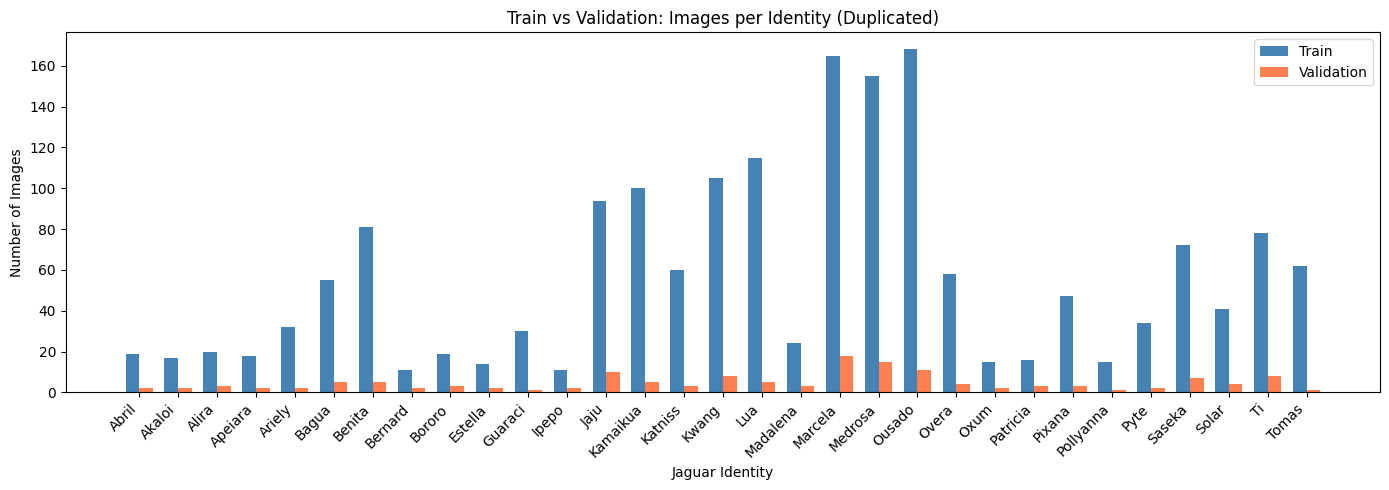


Logged identity distributions to W&B
  Train samples per identity: 11 - 168 (mean: 56.5)
  Val samples per identity: 1 - 18 (mean: 4.6)


In [10]:
# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity (Duplicated)')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution_duplicated": wandb.Image(fig)})
plt.savefig(OUTPUT_PATH / "train_val_distribution_duplicated.png")
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

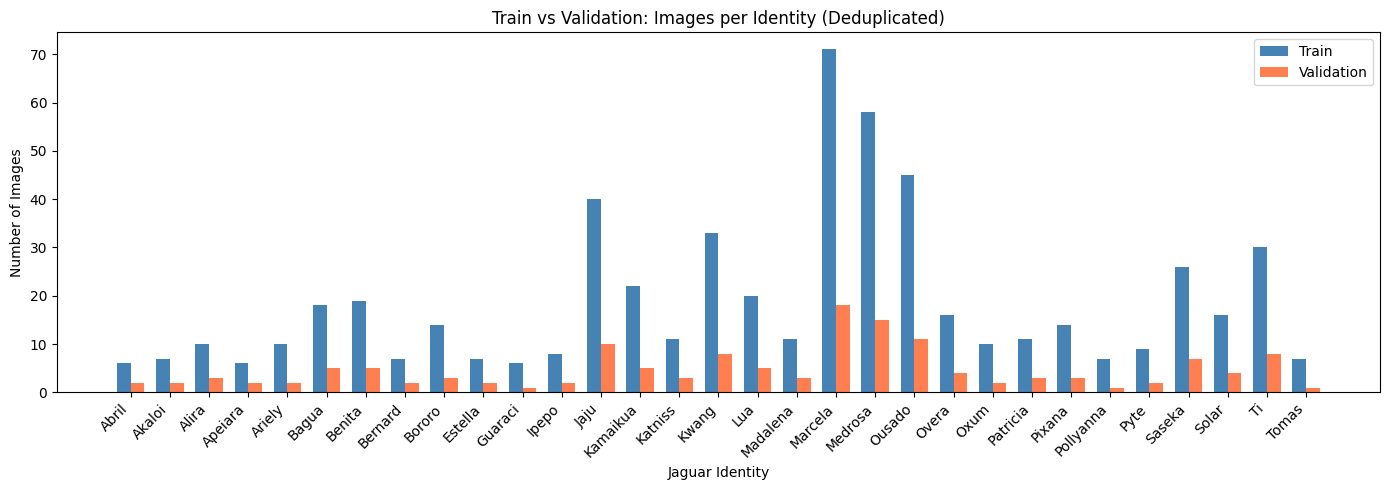


Logged identity distributions to W&B
  Train samples per identity: 6 - 71 (mean: 18.5)
  Val samples per identity: 1 - 18 (mean: 4.6)


In [11]:
# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(deduplicated_train_counts))
ax.bar(x - width/2, deduplicated_train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity (Deduplicated)')
ax.set_xticks(x)
ax.set_xticklabels(deduplicated_train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution_deduplicated": wandb.Image(fig)})
plt.savefig(OUTPUT_PATH / "train_val_distribution_deduplicated.png")
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {deduplicated_train_counts.min()} - {deduplicated_train_counts.max()} (mean: {deduplicated_train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Prepare baseline embeddings

In [12]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [13]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...


Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [14]:
# Define preprocessing pipeline
# MegaDescriptor expects 384x384 images normalized with ImageNet statistics
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Preprocessing pipeline configured:")
print(f"  Resize to: {config['input_size']}x{config['input_size']}")
print(f"  Normalization: ImageNet statistics")

Preprocessing pipeline configured:
  Resize to: 384x384
  Normalization: ImageNet statistics


In [15]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using MegaDescriptor."""
    model.eval()
    embeddings = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        
        # Load and preprocess batch
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                # Use zero tensor as fallback
                batch_tensors.append(torch.zeros(3, config["input_size"], config["input_size"]))
        
        # Stack and move to device
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        # Get embeddings
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)
    
    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [16]:
cache_path = EMBEDDINGS_PATH / "baseline_train_embeddings.npz"

# Extract baseline embeddings for training data
filenames = train_df.index.to_list()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    if cached_filenames == expected_filenames:
        return cached_embeddings

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

baseline_embeddings = None
if cache_path.exists():
    baseline_embeddings = _load_cached_embeddings(cache_path, filenames)
    if baseline_embeddings is not None:
        print(f"Loaded cached baseline embeddings from {cache_path}")
        print(f"Baseline embeddings shape: {baseline_embeddings.shape}")

if baseline_embeddings is None:
    print(f"Extracting baseline embeddings for {len(image_paths)} training images...")
    baseline_embeddings = extract_embeddings(
        megadescriptor,
        image_paths,
        batch_size=config["batch_size"]
    )
    np.savez_compressed(
        cache_path,
        embeddings=baseline_embeddings,
        filenames=np.array(filenames, dtype=object),
    )
    print(f"Saved baseline embeddings cache to {cache_path}")
    print(f"Baseline embeddings shape: {baseline_embeddings.shape}")


Loaded cached baseline embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/duplicate_removal/embeddings/baseline_train_embeddings.npz
Baseline embeddings shape: (1895, 1536)


In [17]:
filenames = np.array(filenames)

train_duplicated_mask = np.isin(filenames, train_data.index)
baseline_train_embeddings = baseline_embeddings[train_duplicated_mask]
train_labels = train_data["label_encoded"].values

print(f"Baseline train embeddings shape: {baseline_train_embeddings.shape}")
print(f"Baseline train labels shape: {train_labels.shape}: {train_labels[:5]}")

train_deduplicated_mask = np.isin(filenames, deduplicated_train_data.index)
baseline_deduplicated_train_embeddings = baseline_embeddings[train_deduplicated_mask]
train_deduplicated_labels = deduplicated_train_data["label_encoded"].values

print(f"Baseline deduplicated train embeddings shape: {baseline_deduplicated_train_embeddings.shape}")
print(f"Baseline deduplicated train labels shape: {train_deduplicated_labels.shape}: {train_deduplicated_labels[:5]}")

val_mask = np.isin(filenames, val_data.index)
baseline_val_embeddings = baseline_embeddings[val_mask]
val_labels = val_data.loc[filenames[val_mask], "label_encoded"].values

print(f"Baseline validation embeddings shape: {baseline_val_embeddings.shape}")
print(f"Baseline validation labels shape: {val_labels.shape}: {val_labels[:5]}")

Baseline train embeddings shape: (1751, 1536)
Baseline train labels shape: (1751,): [0 0 1 1 3]
Baseline deduplicated train embeddings shape: (575, 1536)
Baseline deduplicated train labels shape: (575,): [0 1 1 3 3]
Baseline validation embeddings shape: (144, 1536)
Baseline validation labels shape: (144,): [ 0  8 12 12 15]


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


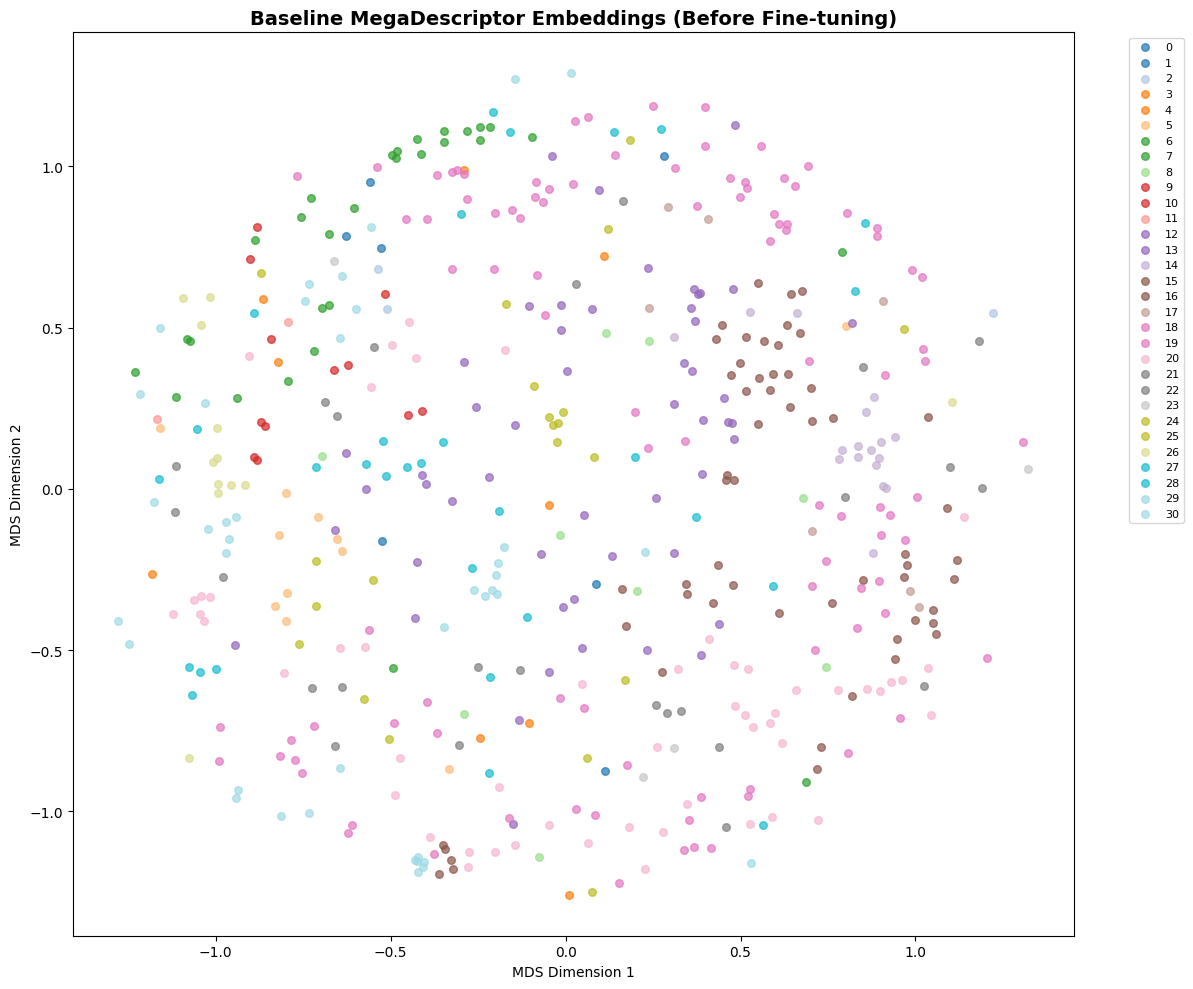

In [18]:
# Visualize baseline embeddings
fig_baseline = visualize_embeddings_mds(
    baseline_train_embeddings,
    train_labels,
    "Baseline MegaDescriptor Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig_baseline)})

## Model definition

In [19]:
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        output = output * self.scale
        
        return output


print("EmbeddingProjection and ArcFaceLayer defined")

EmbeddingProjection and ArcFaceLayer defined


In [20]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


# Create datasets
train_dataset = EmbeddingDataset(
    baseline_train_embeddings, 
    train_labels.tolist()
)
train_dataset_deduplicated = EmbeddingDataset(
    baseline_deduplicated_train_embeddings, 
    train_deduplicated_labels
)
val_dataset = EmbeddingDataset(
    baseline_val_embeddings, 
    val_labels
)

# Create dataloaders
# Note: pin_memory=False for MPS compatibility
train_loader = create_deterministic_training_dataloader(
    train_dataset, 
    batch_size=config["batch_size"], 
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
train_loader_deduplicated = create_deterministic_training_dataloader(
    train_dataset_deduplicated, 
    batch_size=config["batch_size"], 
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config["batch_size"], 
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Deduplicated Train batches: {len(train_loader_deduplicated)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Batch size: {config['batch_size']}")

DataLoaders created:
  Train batches: 55
  Deduplicated Train batches: 18
  Val batches: 5
  Batch size: 32


In [21]:
class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""
    
    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, 
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, 
            num_classes=num_classes,
            margin=margin, 
            scale=scale
        )
    
    def forward(self, x, labels):
        """Forward pass for training (requires labels for ArcFace)."""
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings
    
    def get_embeddings(self, x):
        """Get normalized embeddings for inference."""
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)

print(f"ArcFace Model:")
print(f"  Input dim: {megadescriptor_dim}")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")

print(f"  ArcFace scale: {config['arcface_scale']}")

ArcFace Model:
  Input dim: 1536
  Hidden dim: 512
  Embedding dim: 256
  Dropout: 0.3
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


## Training functions

In [22]:
def compute_validation_map(model, val_embeddings, val_labels):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    with torch.no_grad():
        # Get fine-tuned embeddings
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity
    
    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [23]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")

Training and validation functions defined


In [24]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            baseline_val_embeddings, 
            val_labels
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"arcface_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")
    
    return history, best_val_loss, best_map, best_epoch

print("Train function defined")

Train function defined


In [25]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # mAP
    axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP')
    axes[2].set_title('Validation mAP (Identity-Balanced)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [26]:
table = [
    ["Description", "Best val_loss", "Best val_mAP", "Best epoch"]
]

## Duplicated Model training

In [27]:
# Create model
duplicated_model = ArcFaceModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

print(f"  Total parameters: {sum(p.numel() for p in duplicated_model.parameters()):,}")

  Total parameters: 927,744


In [28]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    duplicated_model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [29]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map_duplicated, best_epoch = train(
    duplicated_model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="duplicated"
)

wandb.log({
    "final_val_loss_duplicated": best_val_loss,
    "final_val_mAP_duplicated": best_map_duplicated,
    "best_epoch_duplicated": best_epoch,
    "total_epochs_duplicated": len(history['train_loss']),
})

table.append([
    "With Duplicates",
    best_val_loss,
    best_map_duplicated,
    best_epoch,
])

All random seeds set to 51 for reproducibility
Starting training for 100 epochs...

Epoch 1/100


Training:   0%|          | 0/55 [00:00<?, ?it/s]

  Train Loss: 35.6256 | Train Acc: 0.0%
  Val Loss:   33.3946 | Val Acc:   0.0%
  Val mAP:    0.2697 | LR: 1.00e-04
  [New best model saved]

Epoch 2/100


  Train Loss: 29.7873 | Train Acc: 0.1%
  Val Loss:   30.1292 | Val Acc:   2.1%
  Val mAP:    0.2794 | LR: 1.00e-04
  [New best model saved]

Epoch 3/100


  Train Loss: 25.8111 | Train Acc: 2.4%
  Val Loss:   27.5798 | Val Acc:   2.1%
  Val mAP:    0.2993 | LR: 1.00e-04
  [New best model saved]

Epoch 4/100


...

  Train Loss: 0.1634 | Train Acc: 96.3%
  Val Loss:   6.9540 | Val Acc:   71.5%
  Val mAP:    0.7570 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 82/100


  Train Loss: 0.1617 | Train Acc: 96.0%
  Val Loss:   6.8741 | Val Acc:   71.5%
  Val mAP:    0.7678 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 83/100


  Train Loss: 0.1572 | Train Acc: 96.1%
  Val Loss:   6.9494 | Val Acc:   71.5%
  Val mAP:    0.7752 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 84/100


  Train Loss: 0.1471 | Train Acc: 96.2%
  Val Loss:   6.9619 | Val Acc:   72.9%
  Val mAP:    0.7641 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 85/100


  Train Loss: 0.1458 | Train Acc: 96.2%
  Val Loss:   6.8639 | Val Acc:   72.2%
  Val mAP:    0.7580 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 85 epochs

Training complete!
Best epoch: 75 (Val Loss: 6.8005, Val mAP: 0.7693)


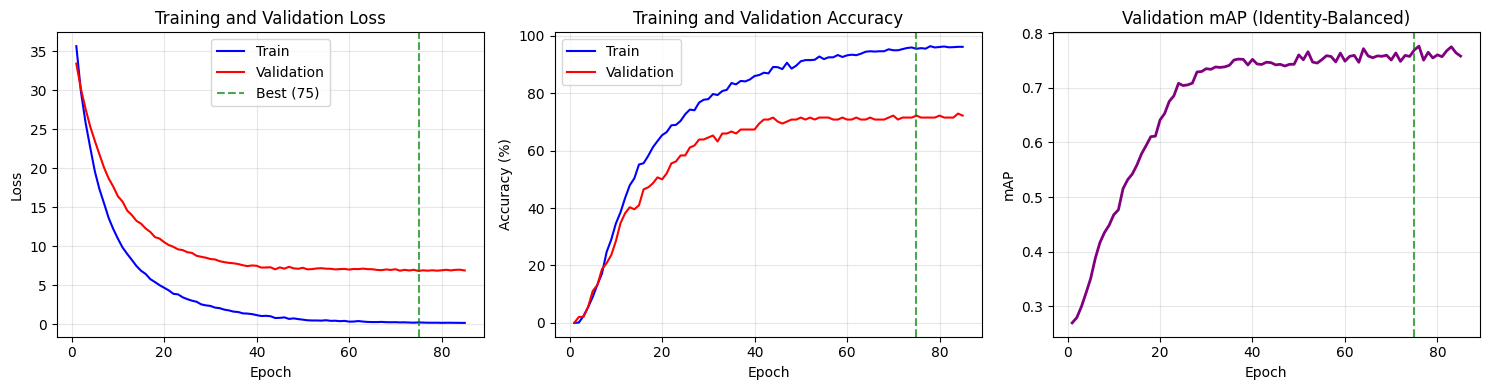

In [30]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_duplicated.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_duplicated": wandb.Image(fig)})

In [31]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_duplicated.pth", map_location=device, weights_only=False)
duplicated_model.load_state_dict(checkpoint['model_state_dict'])
duplicated_model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/duplicate_removal
  Val Loss: 6.8005
  Val mAP: 0.7693


In [32]:
# Extract fine-tuned embeddings for training data
duplicated_model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = duplicated_model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1751, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


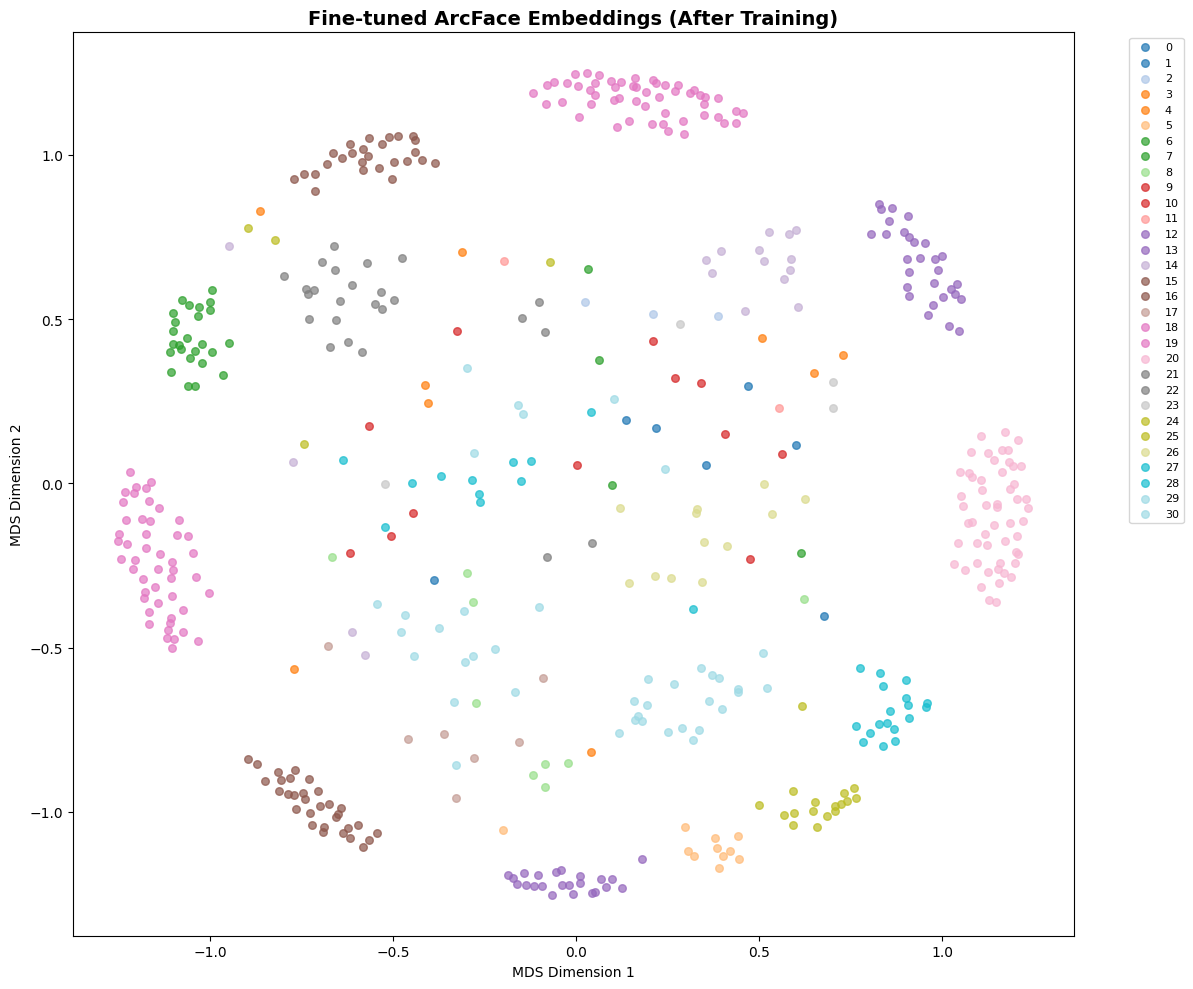

In [33]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "finetuned_embeddings_mds_duplicated.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_duplicated": wandb.Image(fig_finetuned)})

## Without duplicates

In [34]:
# Create model
deduplicated_model = ArcFaceModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

print(f"  Total parameters: {sum(p.numel() for p in deduplicated_model.parameters()):,}")

  Total parameters: 927,744


In [35]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    deduplicated_model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [36]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map_deduplicated, best_epoch = train(
    deduplicated_model, 
    train_loader_deduplicated, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="deduplicated"
)

wandb.log({
    "final_val_loss_deduplicated": best_val_loss,
    "final_val_mAP_deduplicated": best_map_deduplicated,
    "best_epoch_deduplicated": best_epoch,
    "total_epochs_deduplicated": len(history['train_loss']),
})

table.append([
    "Without Duplicates",
    best_val_loss,
    best_map_deduplicated,
    best_epoch,
])

All random seeds set to 51 for reproducibility
Starting training for 100 epochs...

Epoch 1/100


Training:   0%|          | 0/18 [00:00<?, ?it/s, loss=37.7149, acc=0.0%]

  Train Loss: 38.5566 | Train Acc: 0.0%
  Val Loss:   37.1541 | Val Acc:   0.0%
  Val mAP:    0.2577 | LR: 1.00e-04
  [New best model saved]

Epoch 2/100


  Train Loss: 36.5371 | Train Acc: 0.0%
  Val Loss:   35.6856 | Val Acc:   0.0%
  Val mAP:    0.2609 | LR: 1.00e-04
  [New best model saved]

Epoch 3/100


  Train Loss: 34.9791 | Train Acc: 0.0%
  Val Loss:   34.5275 | Val Acc:   0.0%
  Val mAP:    0.2645 | LR: 1.00e-04
  [New best model saved]

Epoch 4/100


...

  Train Loss: 0.4941 | Train Acc: 88.3%
  Val Loss:   15.5767 | Val Acc:   32.6%
  Val mAP:    0.4893 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 92/100


  Train Loss: 0.4227 | Train Acc: 89.0%
  Val Loss:   15.5106 | Val Acc:   31.9%
  Val mAP:    0.4922 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 93/100


  Train Loss: 0.3820 | Train Acc: 89.2%
  Val Loss:   15.4738 | Val Acc:   33.3%
  Val mAP:    0.4916 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 94/100


  Train Loss: 0.3576 | Train Acc: 91.0%
  Val Loss:   15.5573 | Val Acc:   32.6%
  Val mAP:    0.4895 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 95/100


  Train Loss: 0.4087 | Train Acc: 89.4%
  Val Loss:   15.5266 | Val Acc:   32.6%
  Val mAP:    0.4913 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 95 epochs

Training complete!
Best epoch: 85 (Val Loss: 15.4066, Val mAP: 0.4872)


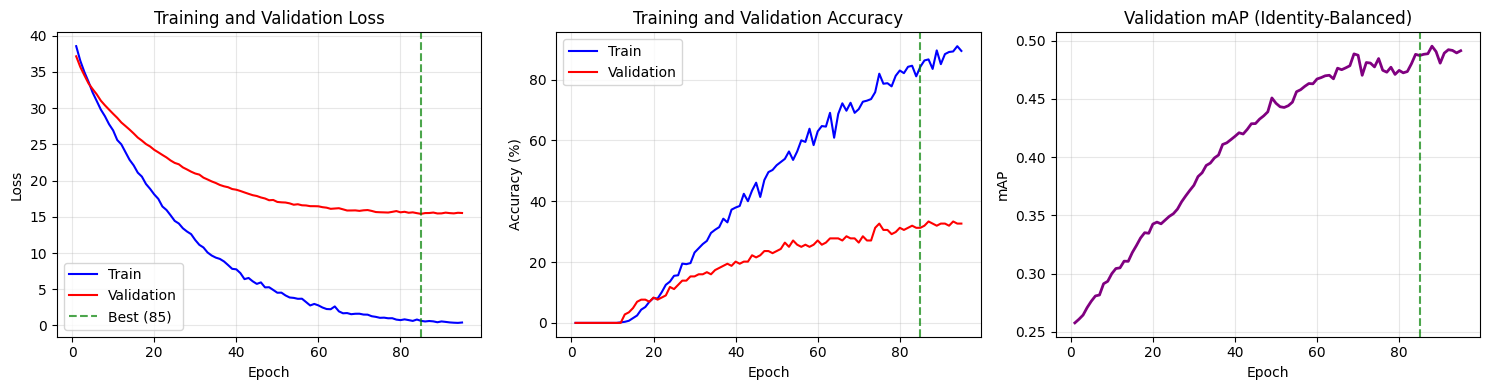

In [37]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_deduplicated.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_deduplicated": wandb.Image(fig)})

In [38]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_deduplicated.pth", map_location=device, weights_only=False)
deduplicated_model.load_state_dict(checkpoint['model_state_dict'])
deduplicated_model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/duplicate_removal
  Val Loss: 15.4066
  Val mAP: 0.4872


In [39]:
# Extract fine-tuned embeddings for training data
deduplicated_model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = deduplicated_model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1751, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


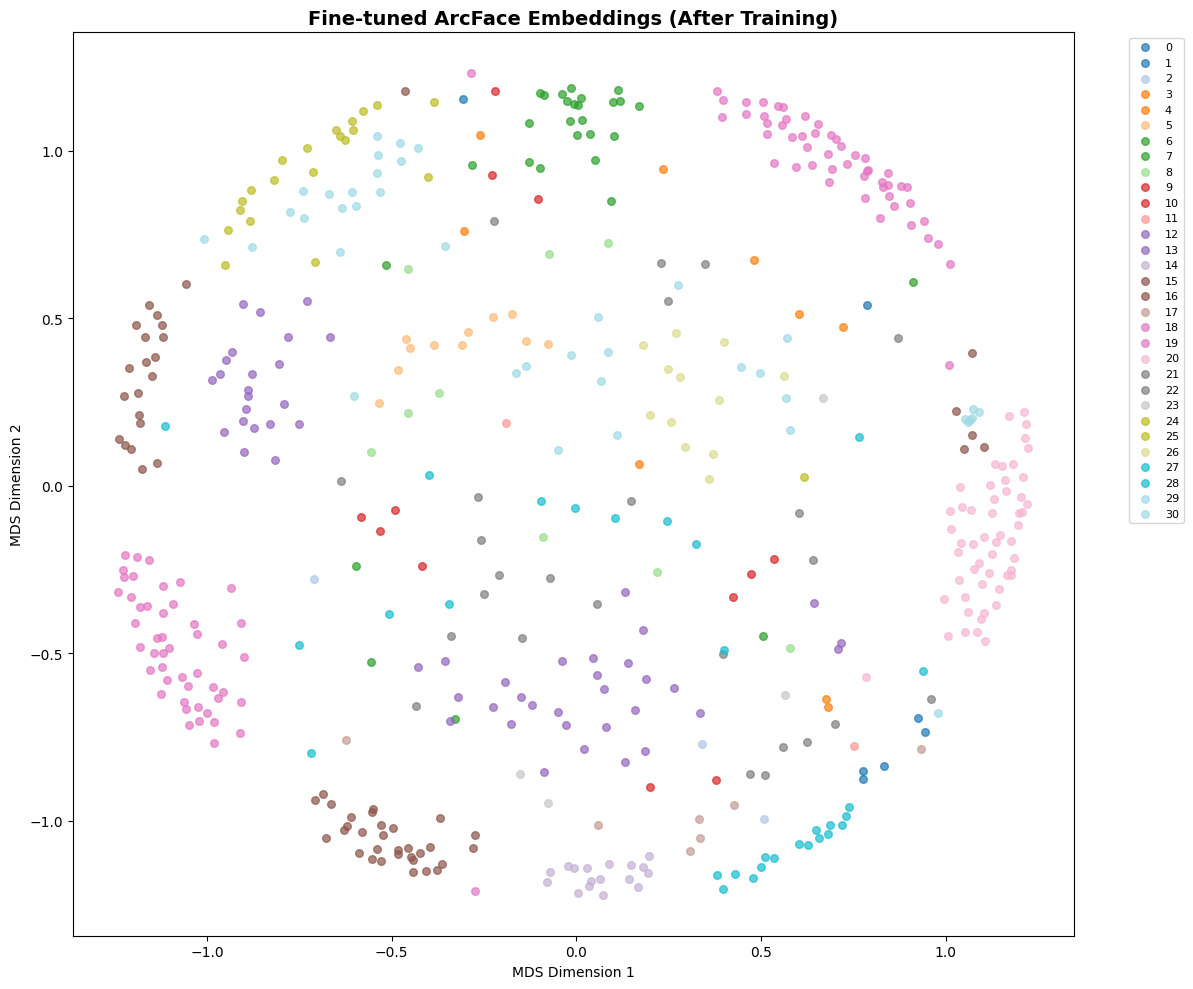

In [40]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "finetuned_embeddings_mds_deduplicated.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_deduplicated": wandb.Image(fig_finetuned)})

## Augmentations

## Comparison

In [41]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+---------------+-------------------+----------------------+
| Description   |   With Duplicates |   Without Duplicates |
+===============+===================+======================+
| Best val_loss |           6.80053 |            15.4066   |
+---------------+-------------------+----------------------+
| Best val_mAP  |           0.76933 |             0.487235 |
+---------------+-------------------+----------------------+
| Best epoch    |          75       |            85        |
+---------------+-------------------+----------------------+


In [42]:
duplicates_in_val = val_data["group"].isin(train_data["group"]).sum()
print(f"\nOverlap between training and validation sets:")
print(f"  Total identities in validation: {len(val_data)}")
print(f"  Identities also in training (duplicated): {duplicates_in_val} ({duplicates_in_val / len(val_data) * 100:.1f}%)")


Overlap between training and validation sets:
  Total identities in validation: 144
  Identities also in training (duplicated): 142 (98.6%)


In [43]:
final_model = None
if best_map_duplicated > best_map_deduplicated:
    final_model = duplicated_model
    print(f"\nBest model: With Duplicates (Val mAP: {best_map_duplicated:.4f})")
else:
    final_model = deduplicated_model
    print(f"\nBest model: Without Duplicates (Val mAP: {best_map_deduplicated:.4f})")



Best model: With Duplicates (Val mAP: 0.7693)


In [44]:
final_model = deduplicated_model

## Submission

In [45]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [46]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

# Extract MegaDescriptor embeddings for test images
print(f"\nExtracting MegaDescriptor embeddings for test images...")
test_mega_embeddings = extract_embeddings(
    megadescriptor,
    test_image_paths,
    batch_size=config["batch_size"],
    desc="Test embeddings"
)

print(f"Test MegaDescriptor embeddings shape: {test_mega_embeddings.shape}")

Unique test images: 371

Extracting MegaDescriptor embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:31<00:00,  7.60s/it]

Test MegaDescriptor embeddings shape: (371, 1536)


In [47]:
# Project through fine-tuned model
final_model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = final_model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [48]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 32421.46it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9917
  Mean: 0.0602
  Std: 0.1173


In [49]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.593391
1       1    0.000000
2       2    0.000000
3       3    0.027322
4       4    0.043096
5       5    0.067493
6       6    0.103414
7       7    0.039717
8       8    0.000000
9       9    0.000000

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [50]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/duplicate_removal/submission.csv
File size: 1809.3 KB


## 11. Save Artifacts to Weights and Biases

In [51]:
# Save model as W&B artifact
model_artifact_duplicated = wandb.Artifact(
    name="arcface-model_duplicated",
    type="model",
    description="ArcFace fine-tuned MegaDescriptor model for jaguar re-identification (with duplicates in training data)"
)
model_artifact_duplicated.add_file(str(CHECKPOINT_PATH / "arcface_best_duplicated.pth"))
wandb.log_artifact(model_artifact_duplicated)

print("Model artifact saved to W&B")

Model artifact saved to W&B


In [52]:
# Save model as W&B artifact
model_artifact_deduplicated = wandb.Artifact(
    name="arcface-model_deduplicated",
    type="model",
    description="ArcFace fine-tuned MegaDescriptor model for jaguar re-identification (without duplicates in training data)"
)
model_artifact_deduplicated.add_file(str(CHECKPOINT_PATH / "arcface_best_deduplicated.pth"))
wandb.log_artifact(model_artifact_deduplicated)

print("Model artifact saved to W&B")

Model artifact saved to W&B


In [53]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description="Competition submission file"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [54]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

best_epoch_deduplicated,▁
best_epoch_duplicated,▁
epoch,▁▁▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▁▂▂▂▃▃▃▄▅▅▅▅▆▆▆▇█
final_val_loss_deduplicated,▁
final_val_loss_duplicated,▁
final_val_mAP_deduplicated,▁
final_val_mAP_duplicated,▁
learning_rate,████████████▃▃▃▃▃▁▁████████████████████▃
num_identities,▁
total_epochs_deduplicated,▁
+9,...


W&B run completed


## Summary